# 04 - EDA: Evaluations Analysis

This notebook analyzes evaluation results from `vlm_evaluations`:
- Glider score distributions by model and task
- Semantic F1 analysis
- Model behavior comparisons
- Score correlations

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))  # artemis_final/
sys.path.insert(0, str(Path.cwd().parent.parent.parent))  # Which_VLM_Router/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from ares.db.connection import get_engine
from ares.configs.db_config import TABLES, MODEL_NAMES

engine = get_engine()
plt.style.use('seaborn-v0_8-whitegrid')
print('Connected!')

Connected!


## 1. Load Evaluation Data

In [28]:
# Join evaluations with samples and responses
query = '''
SELECT 
    s.sample_id, s.source_config, s.router_task, s.data_split, s.ground_truth_type,
    r.model_name, r.is_correct, r.confidence_score, r.score_f1, r.score_exact_match,
    e.glider_score, e.semantic_f1_precision, e.semantic_f1_recall, e.semantic_f1_f1,
    r.latency_ms, r.estimated_cost_usd
FROM vlm_evaluations e
JOIN vlm_samples s ON e.sample_id = s.sample_id
JOIN vlm_responses r ON e.sample_id = r.sample_id AND e.model_name = r.model_name
'''
df = pd.read_sql(query, engine)
print(f'Loaded {len(df)} evaluation records')
print(f'Samples: {df["sample_id"].nunique()}, Models: {df["model_name"].nunique()}')
df.head()

Loaded 269464 evaluation records
Samples: 55729, Models: 5


,sample_id,source_config,router_task,data_split,ground_truth_type,model_name,is_correct,confidence_score,score_f1,score_exact_match,glider_score,semantic_f1_precision,semantic_f1_recall,semantic_f1_f1,latency_ms,estimated_cost_usd
0,dvqa_2_c052b936,dvqa,chart_reasoning,train,exact,qwen3_vl_8b_thinking,False,0.932630,0.000000,0.0,4.0,None,None,None,5537.0,0.000978
1,dvqa_3_4e325e63,dvqa,chart_reasoning,train,exact,qwen2_5_vl_7b,False,0.537369,0.000000,0.0,0.0,None,None,None,345.0,0.000061
2,dvqa_3_8d543b95,dvqa,chart_reasoning,test,exact,qwen2_5_vl_3b,True,0.780347,1.000000,0.0,5.0,None,None,None,3125.0,0.000029
3,dvqa_3_8d543b95,dvqa,chart_reasoning,test,exact,qwen3_vl_8b_thinking,True,0.949981,0.062500,0.0,4.0,None,None,None,859.0,0.000197
4,dvqa_4_c052b936,dvqa,chart_reasoning,train,exact,qwen3_vl_8b_thinking,True,0.900014,0.023256,0.0,0.0,None,None,None,5741.0,0.001117


## 2. Glider Score Analysis

In [29]:
# Glider score summary by model
glider_summary = df.groupby('model_name').agg({
    'glider_score': ['count', 'mean', 'std', 'min', 'max'],
    'is_correct': 'mean',
}).round(3)
glider_summary.columns = ['Count', 'Glider Mean', 'Glider Std', 'Min', 'Max', 'Accuracy']
glider_summary.sort_values('Glider Mean', ascending=False)

,Count,Glider Mean,Glider Std,Min,Max,Accuracy
model_name,,,,,,
qwen2_5_vl_7b,55728,1.316,2.059,0.0,5.0,0.466
qwen3_vl_8b_thinking,55723,1.272,1.904,0.0,5.0,0.465
gemma_3_27b,55721,1.177,1.996,0.0,5.0,0.390
qwen2_5_vl_3b,55729,0.991,1.870,0.0,5.0,0.398
deepseek_ocr,46563,0.388,1.215,0.0,5.0,0.150


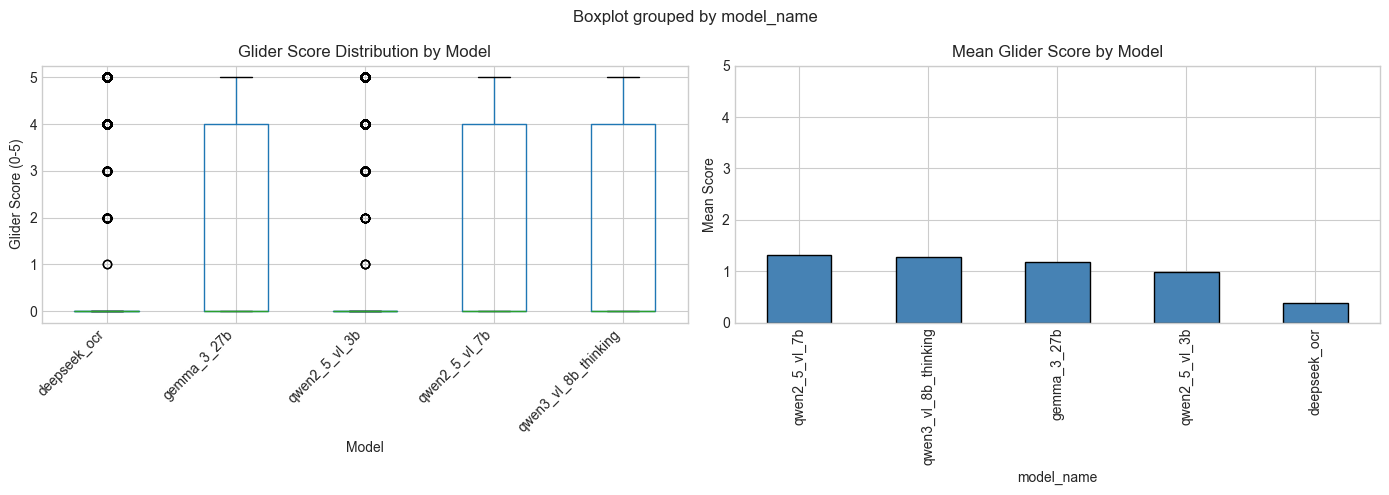

In [30]:
# Glider score distribution by model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='glider_score', by='model_name', ax=axes[0])
axes[0].set_title('Glider Score Distribution by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Glider Score (0-5)')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Bar chart of mean scores
df.groupby('model_name')['glider_score'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Mean Glider Score by Model')
axes[1].set_ylabel('Mean Score')
axes[1].set_ylim(0, 5)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

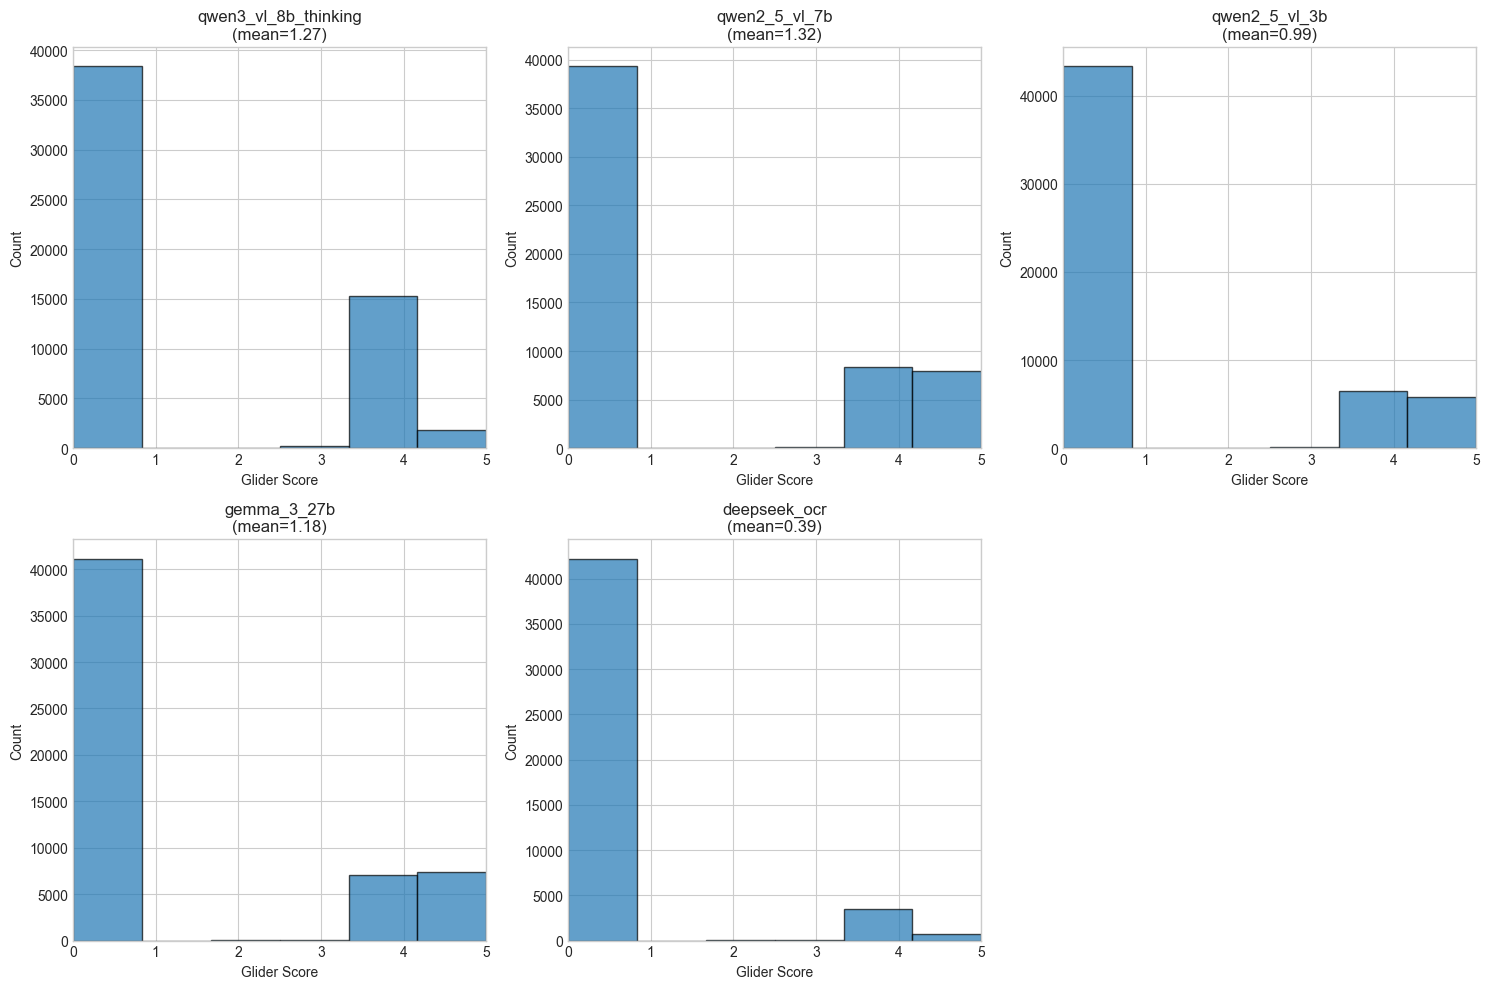

In [31]:
# Glider score histogram by model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, model in enumerate(df['model_name'].unique()[:5]):
    model_data = df[df['model_name'] == model]['glider_score'].dropna()
    axes[idx].hist(model_data, bins=6, range=(0, 5), edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{model}\n(mean={model_data.mean():.2f})')
    axes[idx].set_xlabel('Glider Score')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xlim(0, 5)

if len(axes) > 5:
    axes[5].axis('off')
plt.tight_layout()
plt.show()

## 3. Performance by Task

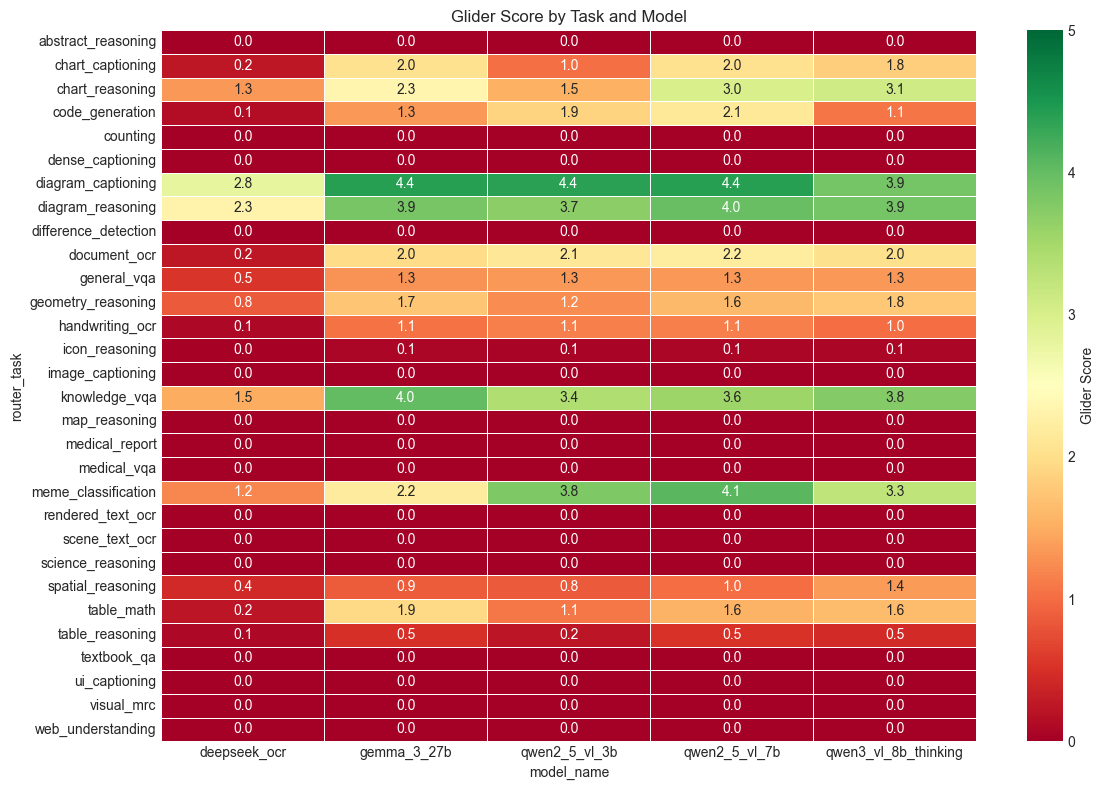

In [32]:
# Glider score by task and model
task_model = df.pivot_table(
    values='glider_score', 
    index='router_task', 
    columns='model_name', 
    aggfunc='mean'
).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(task_model, annot=True, cmap='RdYlGn', vmin=0, vmax=5, fmt='.1f', 
            linewidths=0.5, cbar_kws={'label': 'Glider Score'})
plt.title('Glider Score by Task and Model')
plt.tight_layout()
plt.show()

In [33]:
# Best model per task
best_per_task = task_model.idxmax(axis=1)
print('Best model per task:')
for task, model in best_per_task.items():
    score = task_model.loc[task, model]
    print(f'  {task}: {model} ({score:.2f})')

Best model per task:
  abstract_reasoning: deepseek_ocr (0.00)
  chart_captioning: gemma_3_27b (2.05)
  chart_reasoning: qwen3_vl_8b_thinking (3.10)
  code_generation: qwen2_5_vl_7b (2.14)
  counting: deepseek_ocr (0.00)
  dense_captioning: deepseek_ocr (0.00)
  diagram_captioning: gemma_3_27b (4.41)
  diagram_reasoning: qwen2_5_vl_7b (3.97)
  difference_detection: deepseek_ocr (0.00)
  document_ocr: qwen2_5_vl_7b (2.20)
  general_vqa: qwen2_5_vl_3b (1.33)
  geometry_reasoning: qwen3_vl_8b_thinking (1.76)
  handwriting_ocr: qwen2_5_vl_3b (1.15)
  icon_reasoning: qwen3_vl_8b_thinking (0.07)
  image_captioning: deepseek_ocr (0.00)
  knowledge_vqa: gemma_3_27b (4.01)
  map_reasoning: deepseek_ocr (0.00)
  medical_report: deepseek_ocr (0.00)
  medical_vqa: deepseek_ocr (0.00)
  meme_classification: qwen2_5_vl_7b (4.07)
  rendered_text_ocr: deepseek_ocr (0.00)
  scene_text_ocr: deepseek_ocr (0.00)
  science_reasoning: deepseek_ocr (0.00)
  spatial_reasoning: qwen3_vl_8b_thinking (1.35)
  ta

## 4. Performance by Ground Truth Type

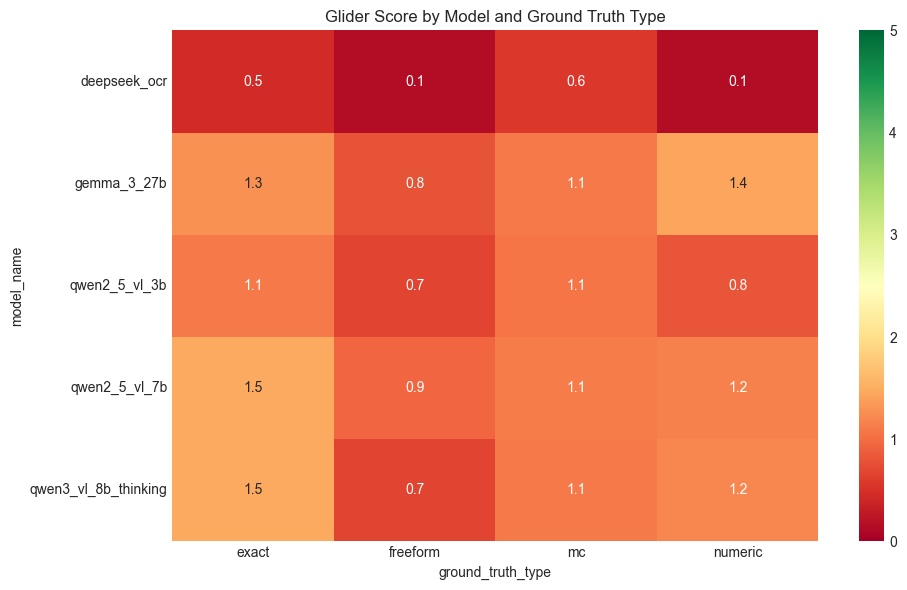

In [34]:
# By ground truth type
gt_pivot = df.pivot_table(
    values='glider_score', 
    index='model_name', 
    columns='ground_truth_type', 
    aggfunc='mean'
).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(gt_pivot, annot=True, cmap='RdYlGn', vmin=0, vmax=5, fmt='.1f')
plt.title('Glider Score by Model and Ground Truth Type')
plt.tight_layout()
plt.show()

## 5. Semantic F1 Analysis

In [35]:
# Semantic F1 summary (if available)
sem_df = df[df['semantic_f1_f1'].notna()]
if len(sem_df) > 0:
    sem_summary = sem_df.groupby('model_name').agg({
        'semantic_f1_precision': 'mean',
        'semantic_f1_recall': 'mean',
        'semantic_f1_f1': 'mean',
    }).round(3)
    sem_summary.columns = ['Precision', 'Recall', 'F1']
    print(f'Semantic F1 evaluated on {len(sem_df)} samples')
    display(sem_summary.sort_values('F1', ascending=False))
else:
    print('No Semantic F1 evaluations found. Run 02_evaluation_scoring with RUN_SEMANTIC_F1=True')

No Semantic F1 evaluations found. Run 02_evaluation_scoring with RUN_SEMANTIC_F1=True


## 6. Score Correlations

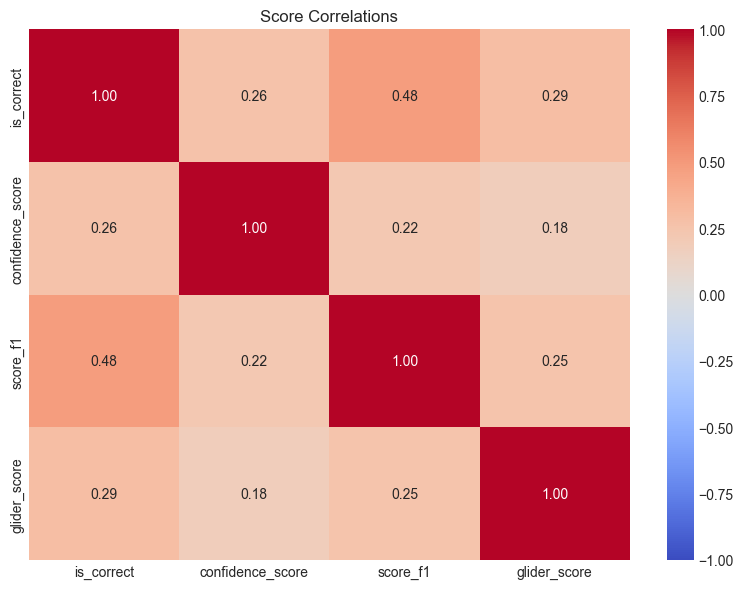

In [36]:
# Correlation between different metrics
score_cols = ['is_correct', 'confidence_score', 'score_f1', 'glider_score']
score_df = df[score_cols].dropna()

if len(score_df) > 10:
    corr = score_df.astype(float).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Score Correlations')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for correlation analysis')

## 7. Glider vs Confidence

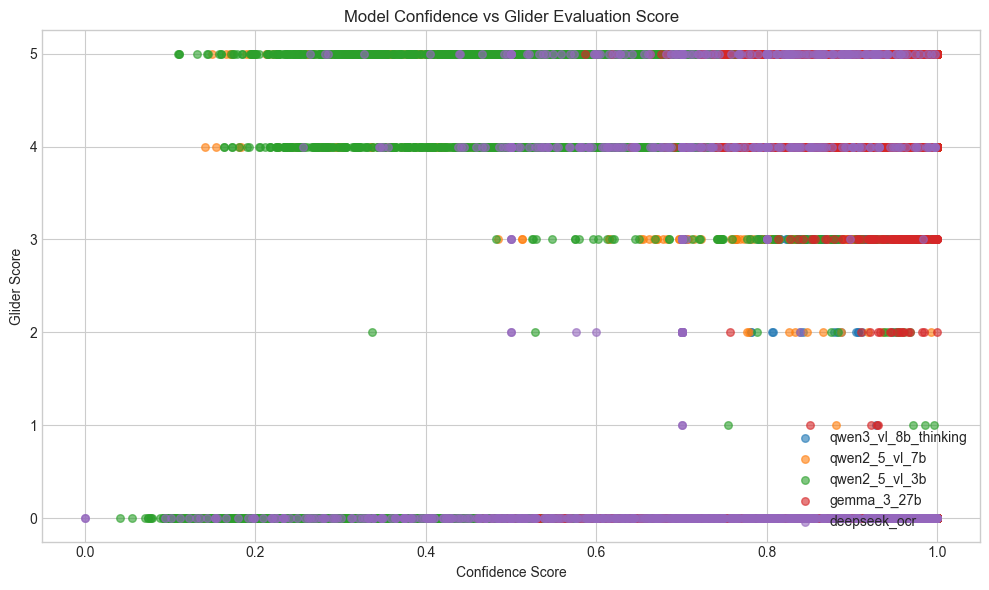

In [37]:
# Scatter: Glider score vs Confidence
plot_df = df[df['confidence_score'].notna() & df['glider_score'].notna()]

fig, ax = plt.subplots(figsize=(10, 6))
for model in plot_df['model_name'].unique():
    m_df = plot_df[plot_df['model_name'] == model]
    ax.scatter(m_df['confidence_score'], m_df['glider_score'], 
               label=model, alpha=0.6, s=30)

ax.set_xlabel('Confidence Score')
ax.set_ylabel('Glider Score')
ax.set_title('Model Confidence vs Glider Evaluation Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Sample Evaluation Reasoning

In [38]:
# View sample Glider reasoning
query = '''
SELECT e.sample_id, e.model_name, e.glider_score, 
       LEFT(e.glider_reasoning, 400) as reasoning,
       s.ground_truth, LEFT(r.response_raw, 200) as response
FROM vlm_evaluations e
JOIN vlm_samples s ON e.sample_id = s.sample_id
JOIN vlm_responses r ON e.sample_id = r.sample_id AND e.model_name = r.model_name
WHERE e.glider_reasoning IS NOT NULL
ORDER BY RANDOM()
LIMIT 3
'''
samples = pd.read_sql(query, engine)

for idx, row in samples.iterrows():
    print('='*70)
    print(f"Sample: {row['sample_id']} | Model: {row['model_name']} | Score: {row['glider_score']}/5")
    print(f"\nGround Truth: {row['ground_truth'][:100]}...")
    print(f"\nResponse: {row['response']}...")
    print(f"\nGlider Reasoning: {row['reasoning']}...")

Sample: finqa_207_86dc6a9b | Model: qwen3_vl_8b_thinking | Score: 5.0/5

Ground Truth: 
Rationale: faster collections lead to an increase in cashflow and decreased borrowing costs general...

Response: Got it, let's find the change in DSO between 2005 and 2006. The problem gives us the DSO values for both years. 

First, let's locate the DSO information. The text says: "Days sales outstanding (dso) ...

Glider Reasoning: - The model's answer is exactly correct, as it matches the ground truth provided.
- The calculation of the change in DSO is accurate and follows the correct method of subtracting the 2005 value from the 2006 value.
- The answer is concise and directly addresses the question without introducing any irrelevant information.
- There are no hallucinations or errors in the answer, ensuring it is fully c...
Sample: textcaps_432_19982558 | Model: deepseek_ocr | Score: 0.0/5

Ground Truth: 3000 is written under a large black i and 14,000 + is written under a black building....


## 9. Summary Statistics

In [39]:
print('='*60)
print('EVALUATION SUMMARY')
print('='*60)
print(f'Total evaluations: {len(df):,}')
print(f'Unique samples: {df["sample_id"].nunique():,}')
print(f'Models: {df["model_name"].nunique()}')
print(f'Tasks: {df["router_task"].nunique()}')
print(f'\nOverall Glider Score: {df["glider_score"].mean():.2f}/5')
print(f'Overall Accuracy: {df["is_correct"].mean():.1%}')

print(f'\nModel Rankings (by Glider score):')
for i, (model, score) in enumerate(df.groupby('model_name')['glider_score'].mean().sort_values(ascending=False).items(), 1):
    print(f'  {i}. {model}: {score:.2f}')

EVALUATION SUMMARY
Total evaluations: 269,464
Unique samples: 55,729
Models: 5
Tasks: 30

Overall Glider Score: 1.05/5
Overall Accuracy: 38.1%

Model Rankings (by Glider score):
  1. qwen2_5_vl_7b: 1.32
  2. qwen3_vl_8b_thinking: 1.27
  3. gemma_3_27b: 1.18
  4. qwen2_5_vl_3b: 0.99
  5. deepseek_ocr: 0.39
